In [ ]:
#------------------------------------------------------------------------------
#
# block 1: initialization and configuration
#
# In this initial block, the notebook sets up the necessary environment for data processing.
# It begins by mounting Google Drive to access stored files, then imports standard libraries
# (like os, glob, gc) and core data science libraries (numpy, pandas, matplotlib, seaborn).
# It also suppresses warnings to keep outputs clean, locates all target CSV files in the
# processed directory, defines a strict list of columns to load to minimize memory overhead,
# and initializes an empty list that will later aggregate individual dataframes.
#
#------------------------------------------------------------------------------

# import colab specific modules and mount google drive
#
from google.colab import drive
drive.mount('/content/drive')

# import system modules
#
import os
import glob
import gc
import warnings
import psutil

# import external modules
#
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# suppress warnings for cleaner notebook output
#
warnings.filterwarnings('ignore')

# define folder containing processed csv files in google drive
#
PROCESSED_FOLDER = "/content/drive/MyDrive/processed"

# fetch all csv files from the processed folder
#
all_files = glob.glob(os.path.join(PROCESSED_FOLDER, "*.csv"))

if not all_files:
    print(f"ERROR: No CSV files found in {PROCESSED_FOLDER}.")

# define exact columns to load to minimize memory footprint
#
use_cols = [
    'Timestamp', 'Temperature', 'Setpoint', 'FanState', 'OutputState',
    'RunningMode', 'RunningMode_cool', 'RunningMode_heat', 'RunningMode_off',
    'CumulativeRuntime', 'CumulativeCost', 'Year', 'Month', 'Day',
    'Outdoor_Temperature', 'outsideMinTemp', 'outsideMaxTemp', 'outsideHumidity'
]

# initialize an empty list to hold the optimized dataframe chunks
#
df_list = []

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
#------------------------------------------------------------------------------
#
# block 2: main data aggregation loop
#
# This block iteratively loads and processes each CSV file found in the data directory.
# To manage hardware memory constraints, it aggressively downcasts numerical data types
# (converting 64-bit floats and integers to smaller 32-bit, 16-bit, or 8-bit variants)
# and converts string features into memory-efficient pandas categorical data types.
# Additionally, it performs row-level feature engineering such as calculating time elapsed
# between records, deriving temperature errors (actual vs setpoint), extracting day and hour
# components from timestamps, and calculating incremental operating costs. The processed
# dataframes are appended to a list for later concatenation, with immediate garbage collection.
#
#------------------------------------------------------------------------------

# iterate through every discovered processed file
#
for file in all_files:

    # monitor hardware ram to prevent colab container crash
    #
    if psutil.virtual_memory().percent > 80.0:
        print("WARNING: Hardware memory limit reached (>80%). Halting file load.")
        break

    # load csv utilizing the column list
    #
    temp_df = pd.read_csv(file, usecols=lambda c: c in use_cols)

    # downcast 64-bit floats to 32-bit
    #
    float_cols = temp_df.select_dtypes(include=['float64']).columns
    temp_df[float_cols] = temp_df[float_cols].astype('float32')

    # downcast 64-bit integers to 8-bit or 16-bit
    #
    int_cols = temp_df.select_dtypes(include=['int64']).columns
    temp_df[int_cols] = temp_df[int_cols].apply(pd.to_numeric, downcast='integer')

    # cast timestamp strings to datetime objects and sort chronologically
    #
    temp_df['Timestamp'] = pd.to_datetime(temp_df['Timestamp'])
    temp_df = temp_df.sort_values('Timestamp')

    # extract the raw filename to use as an identifier
    #
    temp_df['House_ID'] = os.path.basename(file)

    # calculate chronological elapsed time between logs
    #
    temp_df['Time_Delta'] = temp_df['Timestamp'].diff().dt.total_seconds().fillna(0).clip(lower=0)

    # calculate deviation between setpoint and actual temperature
    #
    temp_df['Temperature_Error'] = temp_df['Temperature'] - temp_df['Setpoint']

    # reconstruct active mode string
    #
    temp_df['Active_Mode'] = 'Off / Other'
    if 'RunningMode_heat' in temp_df.columns and 'RunningMode_cool' in temp_df.columns:
        temp_df.loc[temp_df['RunningMode_heat'] == 1, 'Active_Mode'] = 'Heat'
        temp_df.loc[temp_df['RunningMode_cool'] == 1, 'Active_Mode'] = 'Cool'

    # calculate row-by-row delta of active output cost
    #
    temp_df['Cost_Diff'] = temp_df['CumulativeCost'].diff().fillna(0).clip(lower=0)

    # extract string name for day of week and integer for hour
    #
    temp_df['DayOfWeek'] = temp_df['Timestamp'].dt.day_name()
    temp_df['Hour'] = temp_df['Timestamp'].dt.hour

    # cast strings to memory-mapped category dicts
    #
    temp_df['Active_Mode'] = temp_df['Active_Mode'].astype('category')
    temp_df['DayOfWeek'] = temp_df['DayOfWeek'].astype('category')
    temp_df['House_ID'] = temp_df['House_ID'].astype('category')

    # append the compressed dataframe to the list
    #
    df_list.append(temp_df)

    # discard intermediate variables and force garbage collection
    #
    del temp_df
    gc.collect()

In [ ]:
#------------------------------------------------------------------------------
#
# block 3: master dataframe finalization
#
# After all individual CSV files are loaded and optimized, this block concatenates
# the list of temporary dataframes into a single, unified master dataframe. Because
# pandas sometimes loses categorical typings during concatenation, those columns are
# explicitly recast to conserve memory. It then executes some global aggregations,
# summing costs and elapsed time by operational mode, and creating an hour-by-day
# summary of fan states. Finally, it completely purges the initial list structure
# from RAM to free up resources.
#
#------------------------------------------------------------------------------

# concatenate all data into a single master dataframe
#
master_df = pd.concat(df_list, ignore_index=True)

# re-cast categorical columns after concatenation
#
master_df['Active_Mode'] = master_df['Active_Mode'].astype('category')
master_df['DayOfWeek'] = master_df['DayOfWeek'].astype('category')
master_df['House_ID'] = master_df['House_ID'].astype('category')

# group metrics by active hvac mode across the entire dataset
#
mode_totals = master_df.groupby('Active_Mode', observed=True).agg(
    Cost_Diff=('Cost_Diff', 'sum'),
    Time_Delta=('Time_Delta', 'sum')
).reset_index()

# generate averaged cyclic trends from unified data
#
hour_day_df = master_df.groupby(['DayOfWeek', 'Hour'], observed=True)[['Cost_Diff', 'FanState']].mean().reset_index()

# aggressively clear the list structure from memory
#
del df_list
gc.collect()

# output preview block
#
display(master_df.head(3))

,Timestamp,Temperature,Setpoint,FanState,OutputState,RunningMode_cool,RunningMode_heat,RunningMode_off,CumulativeRuntime,CumulativeCost,...,outsideMinTemp,outsideMaxTemp,outsideHumidity,House_ID,Time_Delta,Temperature_Error,Active_Mode,Cost_Diff,DayOfWeek,Hour
0,2025-02-13 12:32:53,24.150000,24.440001,0.0,0.0,0.0,0.0,1.0,0.0,0.00000,...,-1.44,0.58,71.0,processed_timeseries_table_timeseries_table (1...,0.0,-0.290001,Off / Other,0.00000,Thursday,12
1,2025-02-13 12:33:29,23.860001,24.440001,1.0,1.0,0.0,1.0,0.0,0.0,0.00000,...,-1.44,0.58,71.0,processed_timeseries_table_timeseries_table (1...,36.0,-0.580000,Heat,0.00000,Thursday,12
2,2025-02-13 12:33:35,23.700001,24.440001,1.0,1.0,0.0,1.0,0.0,6.0,0.00085,...,-1.44,0.58,71.0,processed_timeseries_table_timeseries_table (1...,6.0,-0.740000,Heat,0.00085,Thursday,12


In [ ]:
#------------------------------------------------------------------------------
#
# block 3.5: feature engineering - extract temporal components
#
# This block handles late-stage feature engineering focused specifically on
# extracting granular temporal properties from the timestamp. It isolates the
# numerical month and the discrete calendar date into dedicated columns.
# Having these components readily available drastically simplifies subsequent
# grouping and aggregation tasks aimed at identifying seasonal trends or daily totals.
#
#------------------------------------------------------------------------------

# extract month as an integer from the datetime timestamp
#
master_df['Month'] = master_df['Timestamp'].dt.month

# also ensure Date is available for any blocks that might have missed it
#
master_df['Date'] = master_df['Timestamp'].dt.date

print(f"'Month' column successfully derived. Unique months: {master_df['Month'].unique()}")
display(master_df[['Timestamp', 'Month', 'Date']].head(3))

'Month' column successfully derived. Unique months: [ 2  3  4  5  6  7  8  9 10 11 12  1]


,Timestamp,Month,Date
0,2025-02-13 12:32:53,2,2025-02-13
1,2025-02-13 12:33:29,2,2025-02-13
2,2025-02-13 12:33:35,2,2025-02-13


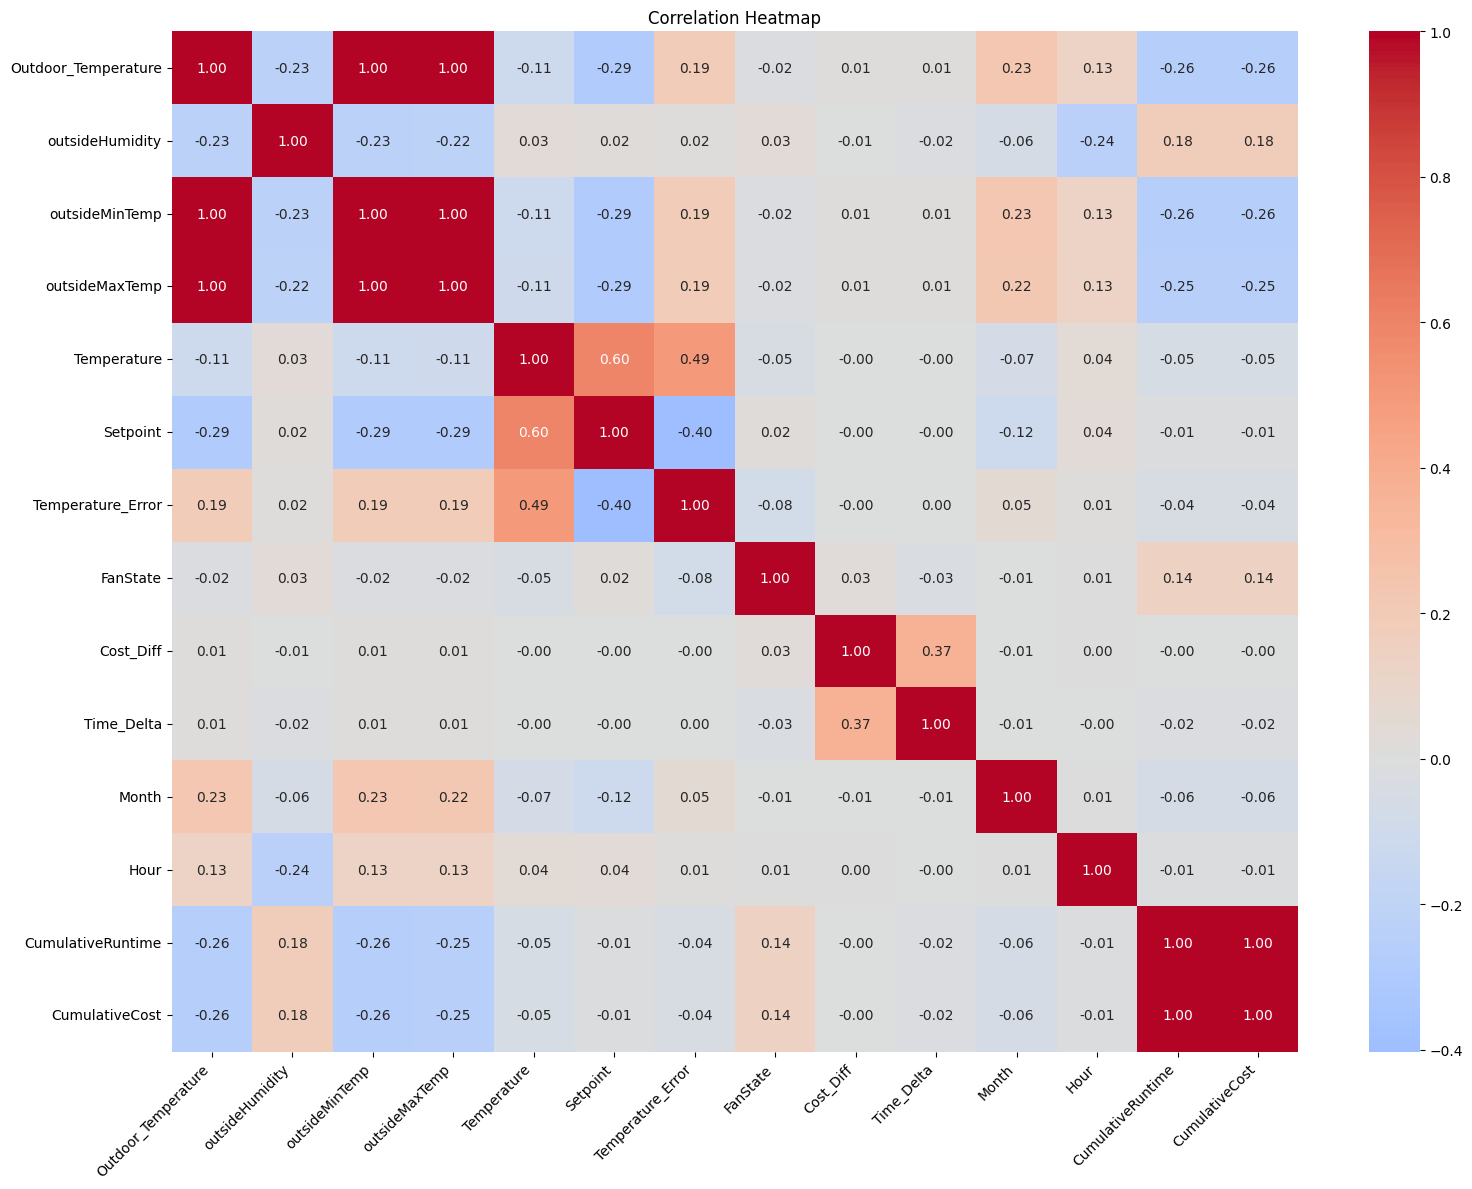

In [ ]:
#------------------------------------------------------------------------------
#
# block 5: correlation heatmap
#
# This block generates a Pearson correlation matrix for a specific subset of features
# to explore linear relationships between environmental conditions, system settings,
# and operational costs. It filters the master dataset for available target columns,
# computes the correlations, and visualizes them using a seaborn heatmap. The
# annotations are restricted to two decimal places for readability, helping to quickly
# identify variables that might strongly influence runtime or cost.
#
#------------------------------------------------------------------------------

# establish figure canvas
#
plt.figure(figsize=(16, 12))

# filter expanded target features for correlation logic
#
corr_features = [
    'Outdoor_Temperature', 'outsideHumidity', 'outsideMinTemp', 'outsideMaxTemp',
    'Temperature', 'Setpoint', 'Temperature_Error', 'FanState', 'Cost_Diff', 'Time_Delta',
    'Month', 'Hour', 'Runtime_Diff', 'CumulativeRuntime', 'CumulativeCost'
]
available_features = [c for c in corr_features if c in master_df.columns]

# calculate pearson correlation matrix
#
corr_matrix = master_df[available_features].corr()

# plot heatmap of the correlations restricting annotations to 2 decimal places
#
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0)

# configure labels and rotate long axis titles to prevent overlap
#
plt.title('Correlation Heatmap')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Heating Total Cost: $48765.24, Cooling Total Cost: $53987.94
Percentage Difference in Cost: 10.17%
Heating Total Time: 475061270s, Cooling Total Time: 570668515s
Percentage Difference in Time: 18.29%
Conclusion: Supported. Heating and cooling modes exhibit comparable active workloads and total costs.


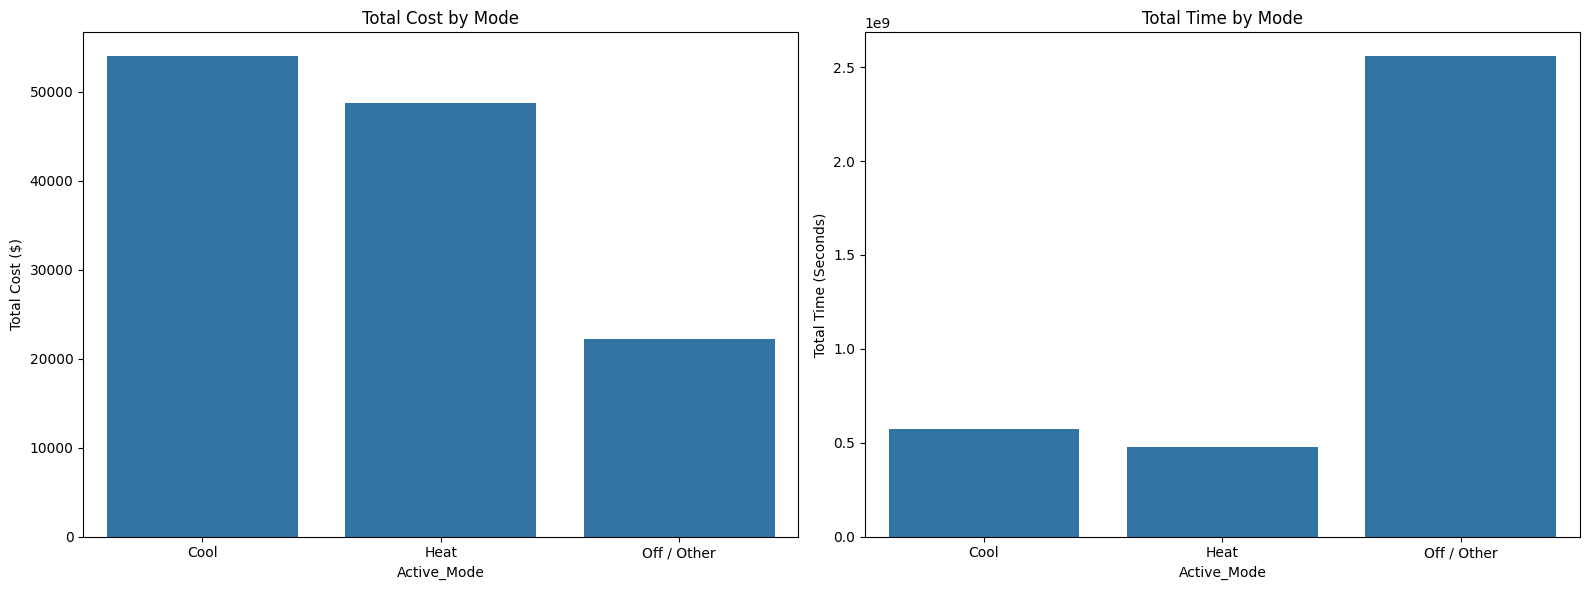

In [ ]:
# Data Report Quote: 'Heating and cooling modes exhibit comparable active workloads and total costs.'
#------------------------------------------------------------------------------
#
# block 6: mode cost and time comparison
#
# This block evaluates the hypothesis that heating and cooling modes incur similar
# costs and workloads. It groups the master dataframe by active mode, aggregates
# the total incremental cost and elapsed time, and calculates the percentage difference
# between heating and cooling. It then prints whether the hypothesis is supported or
# disproven based on a 25% tolerance threshold. Finally, it provides a visual
# side-by-side comparison of total costs and elapsed time across operating modes
# using bar plots.
#
#------------------------------------------------------------------------------

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# ensure Cost_Diff and Time_Delta are in master_df
if 'Cost_Diff' not in master_df.columns:
    master_df['Cost_Diff'] = master_df['CumulativeCost'].diff().fillna(0).clip(lower=0)
if 'Time_Delta' not in master_df.columns:
    master_df['Time_Delta'] = master_df['Timestamp'].diff().dt.total_seconds().fillna(0).clip(lower=0)

# group metrics by active hvac mode across the entire dataset
mode_totals = master_df.groupby('Active_Mode', observed=True).agg(
    Cost_Diff=('Cost_Diff', 'sum'),
    Time_Delta=('Time_Delta', 'sum')
).reset_index()

# Extract totals for 'Heat' and 'Cool' modes
heat_totals = mode_totals[mode_totals['Active_Mode'] == 'Heat']
cool_totals = mode_totals[mode_totals['Active_Mode'] == 'Cool']

if not heat_totals.empty and not cool_totals.empty:
    heat_cost = heat_totals['Cost_Diff'].values[0]
    cool_cost = cool_totals['Cost_Diff'].values[0]

    heat_time = heat_totals['Time_Delta'].values[0]
    cool_time = cool_totals['Time_Delta'].values[0]

    # Calculate percentage differences
    cost_pct_diff = abs(heat_cost - cool_cost) / np.mean([heat_cost, cool_cost]) * 100
    time_pct_diff = abs(heat_time - cool_time) / np.mean([heat_time, cool_time]) * 100

    print(f"Heating Total Cost: ${heat_cost:.2f}, Cooling Total Cost: ${cool_cost:.2f}")
    print(f"Percentage Difference in Cost: {cost_pct_diff:.2f}%")

    print(f"Heating Total Time: {heat_time:.0f}s, Cooling Total Time: {cool_time:.0f}s")
    print(f"Percentage Difference in Time: {time_pct_diff:.2f}%")

    if cost_pct_diff < 25 and time_pct_diff < 25:
        print("Conclusion: Supported. Heating and cooling modes exhibit comparable active workloads and total costs.")
    else:
        print("Conclusion: Disproven. The differences in cost and/or time between modes are notable (>25%).")
else:
    print("Could not compute differences. Heat or Cool data is missing.")

# establish subplots canvas
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# plot left bar graph containing the total cost comparison
sns.barplot(data=mode_totals, x='Active_Mode', y='Cost_Diff', ax=axes[0])
axes[0].set_title('Total Cost by Mode')
axes[0].set_ylabel('Total Cost ($)')

# plot right bar graph containing the total elapsed chronological time
sns.barplot(data=mode_totals, x='Active_Mode', y='Time_Delta', ax=axes[1])
axes[1].set_title('Total Time by Mode')
axes[1].set_ylabel('Total Time (Seconds)')

# commit layout
plt.tight_layout()
plt.show()

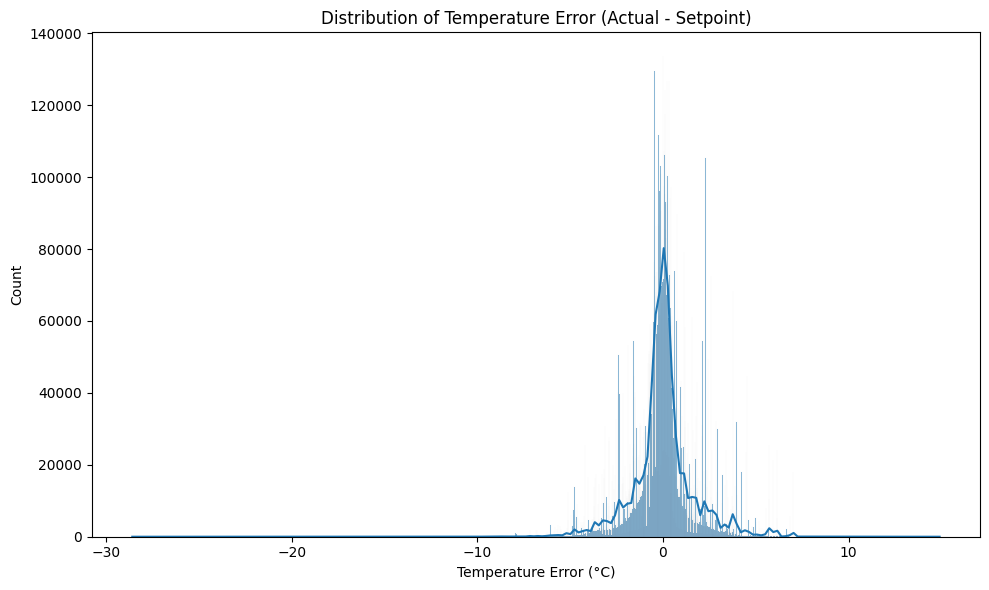

In [ ]:
#------------------------------------------------------------------------------
#
# block 7: temperature error distribution
#
# This block visualizes the distribution of the temperature error, defined as the
# difference between the actual indoor temperature and the user's setpoint. It drops
# any missing values to ensure accurate plotting and uses a seaborn histogram with a
# kernel density estimate (KDE) overlay to illustrate the spread, central tendency,
# and potential skewness of the system's ability to maintain the target temperature.
#
#------------------------------------------------------------------------------

# establish figure canvas
#
plt.figure(figsize=(10, 6))

# isolate valid errors and plot distribution
#
valid_error = master_df['Temperature_Error'].dropna()
sns.histplot(valid_error, kde=True)

# configure labels
#
plt.title('Distribution of Temperature Error (Actual - Setpoint)')
plt.xlabel('Temperature Error (°C)')
plt.tight_layout()
plt.show()

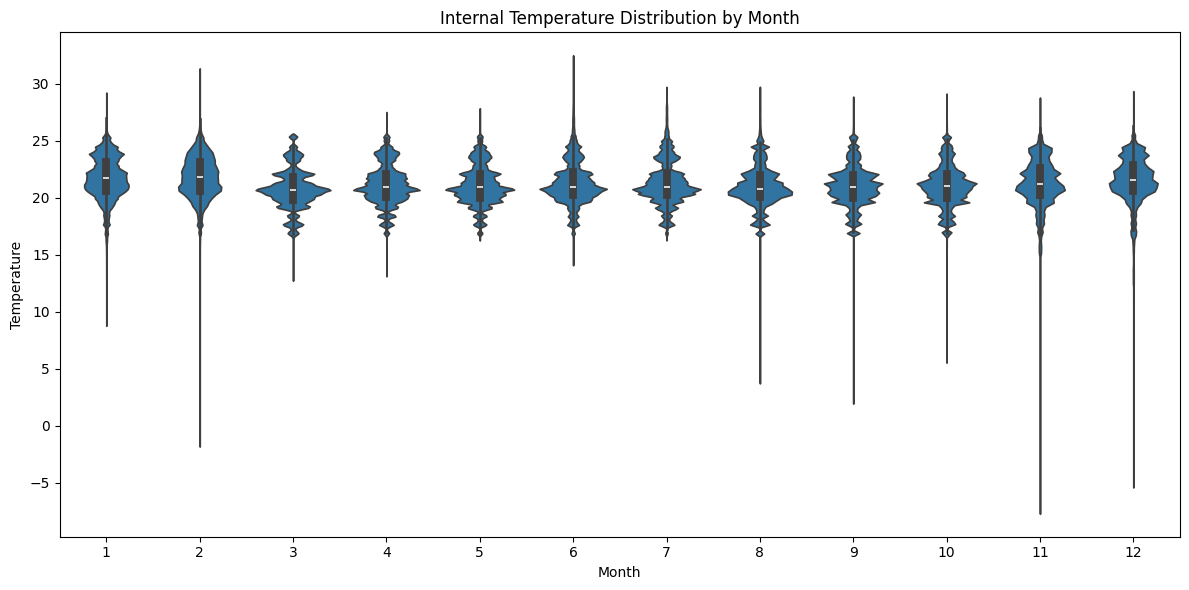

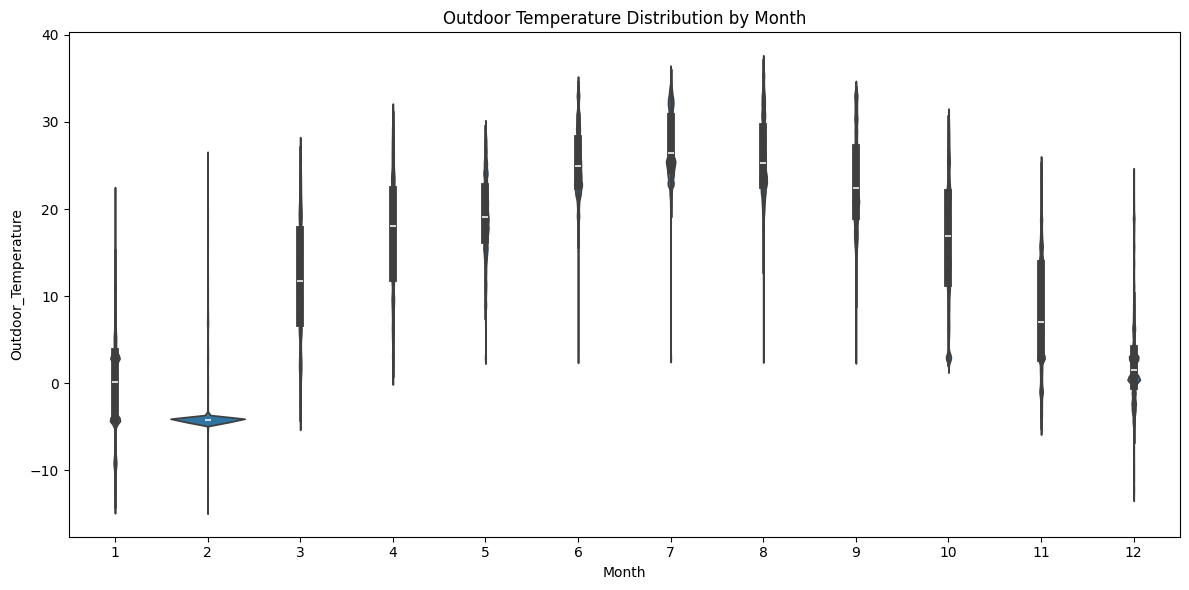

In [ ]:
#------------------------------------------------------------------------------
#
# block 8: temperature distributions by month
#
# This block explores seasonal variations in both indoor and outdoor temperatures
# by generating violin plots broken down by month. The violin plots effectively show
# the probability density of the temperature data at different values, highlighting
# median temperatures and the overall spread. The first plot displays internal
# household temperatures, while the second provides context by showing outdoor temperatures.
#
#------------------------------------------------------------------------------

# establish figure canvas for internal temp distribution
#
plt.figure(figsize=(12, 6))

# plot violin distribution across months
#
sns.violinplot(data=master_df, x='Month', y='Temperature')
plt.title('Internal Temperature Distribution by Month')
plt.tight_layout()
plt.show()

# establish figure canvas for outdoor temp distribution
#
plt.figure(figsize=(12, 6))

# plot violin distribution across months
#
sns.violinplot(data=master_df, x='Month', y='Outdoor_Temperature')
plt.title('Outdoor Temperature Distribution by Month')
plt.tight_layout()
plt.show()

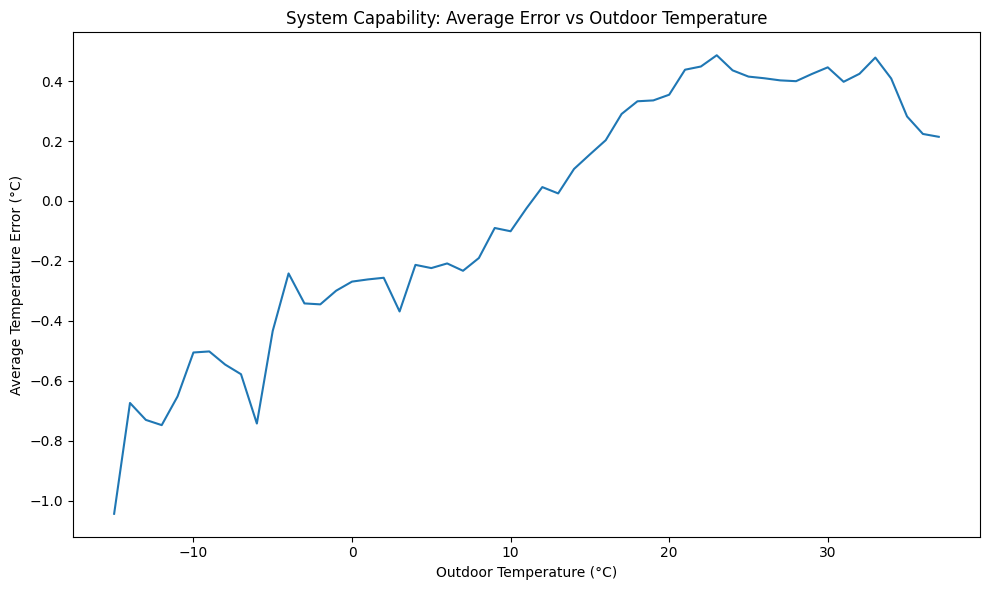

In [ ]:

#------------------------------------------------------------------------------
#
# block 9: system capability vs binned outdoor temperature
#
# This block attempts to assess HVAC system capability as outdoor weather becomes
# more extreme. It rounds the outdoor temperature to the nearest whole degree to
# create discrete bins, then computes the average temperature error within each bin.
# By plotting these averages as a line chart, we can observe if the system struggles
# (i.e., higher error) during extremely hot or cold outdoor conditions.
#
#------------------------------------------------------------------------------

# establish figure canvas
#
plt.figure(figsize=(10, 6))

# round outdoor temperature to nearest degree for binned trendline
#
master_df['Outdoor_Bin'] = master_df['Outdoor_Temperature'].round(0)
bin_df = master_df.groupby('Outdoor_Bin', observed=True)['Temperature_Error'].mean().reset_index()

# plot average error per temperature bin
#
sns.lineplot(data=bin_df, x='Outdoor_Bin', y='Temperature_Error')

# configure labels
#
plt.title('System Capability: Average Error vs Outdoor Temperature')
plt.xlabel('Outdoor Temperature (°C)')
plt.ylabel('Average Temperature Error (°C)')
plt.tight_layout()
plt.show()

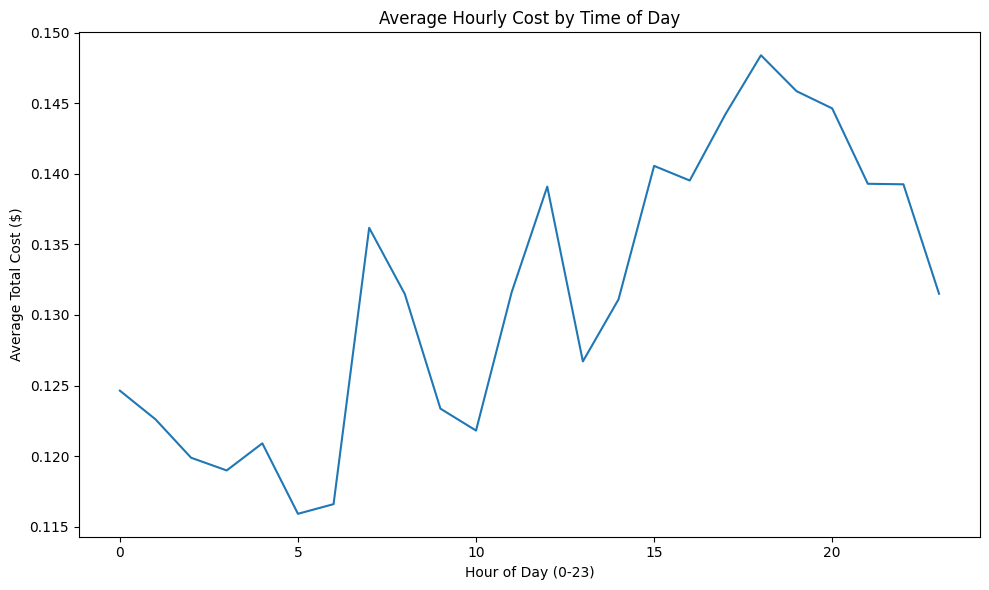

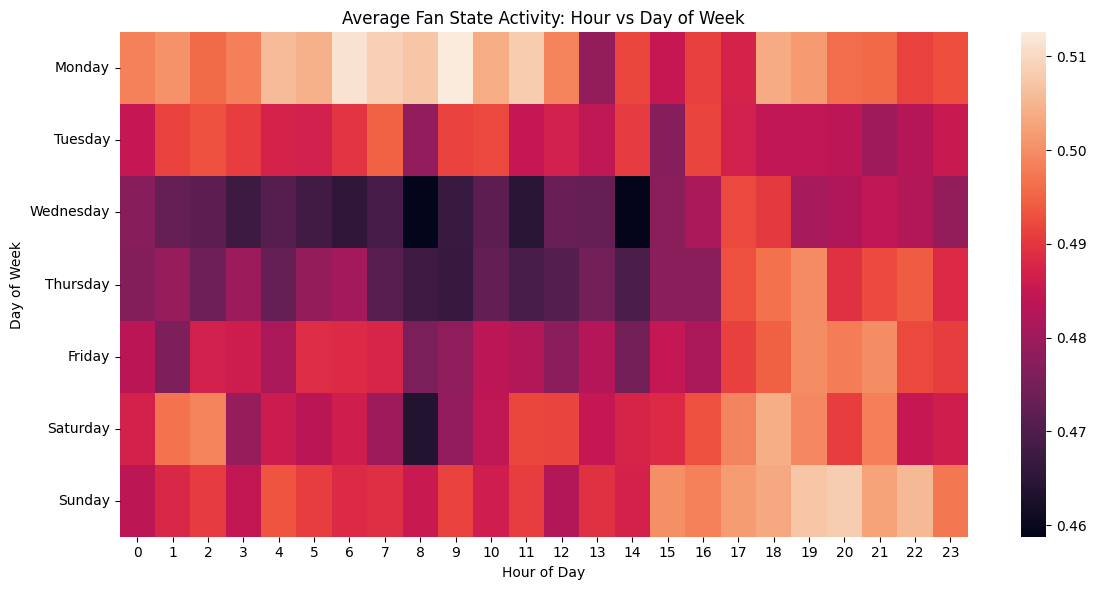

In [ ]:
#------------------------------------------------------------------------------
#
# block 10: hourly operations and fan state
#
#------------------------------------------------------------------------------

# establish figure canvas for average hourly costs
#
plt.figure(figsize=(10, 6))

# extract the discrete date to isolate unique historical hours
#
master_df['Date'] = master_df['Timestamp'].dt.date

# sum the incremental costs for every unique hour per house
#
hourly_actuals = master_df.groupby(['House_ID', 'Date', 'Hour'], observed=True)['Cost_Diff'].sum().reset_index()

# calculate the mean average of those 1-hour total blocks
#
hourly_cost = hourly_actuals.groupby('Hour')['Cost_Diff'].mean().reset_index()

# plot cyclic cost trend
#
sns.lineplot(data=hourly_cost, x='Hour', y='Cost_Diff')

# configure labels
#
plt.title('Average Hourly Cost by Time of Day')
plt.xlabel('Hour of Day (0-23)')
plt.ylabel('Average Total Cost ($)')
plt.tight_layout()
plt.show()

# establish figure canvas for cyclic fan state heatmap
#
plt.figure(figsize=(12, 6))

# generate pivot table for hour vs day of week
#
fan_pivot = hour_day_df.pivot_table(index='DayOfWeek', columns='Hour', values='FanState', aggfunc='mean', observed=True)
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
fan_pivot = fan_pivot.reindex(days_order)

# plot heatmap of average fan activity
#
sns.heatmap(fan_pivot)

# configure labels
#
plt.title('Average Fan State Activity: Hour vs Day of Week')
plt.xlabel('Hour of Day')
plt.ylabel('Day of Week')
plt.tight_layout()
plt.show()

Time spent in 'Off / Other' state: 70.98%
Conclusion: Supported. Systems spend the vast majority of their time in an idle or off state.


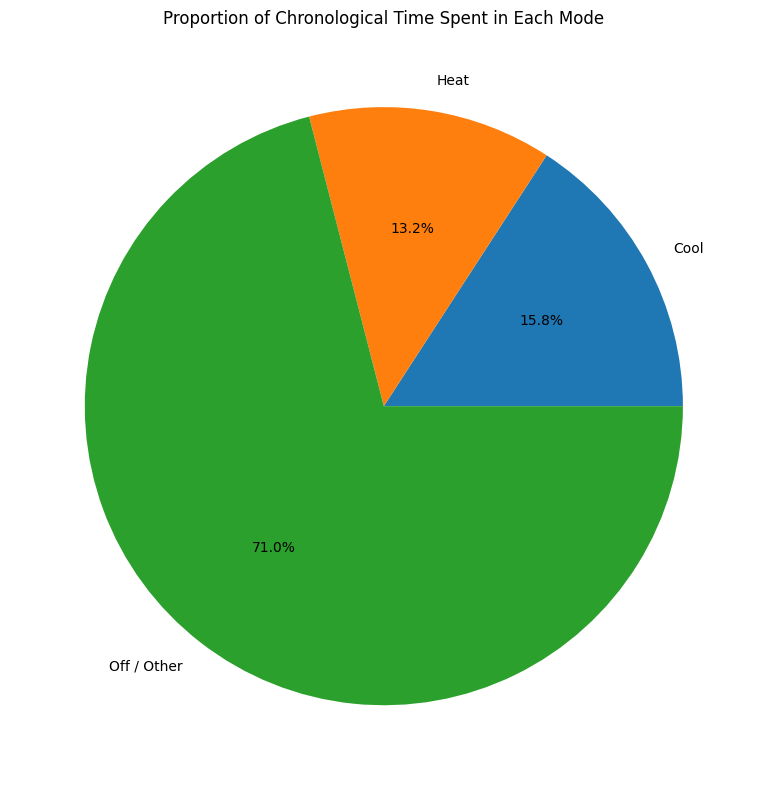

In [ ]:
# Data Report Quote: 'Systems spend the vast majority of their time in an idle or off state.'
#------------------------------------------------------------------------------
#
# block 11: proportion of time by mode
#
#------------------------------------------------------------------------------

import matplotlib.pyplot as plt

# Calculate total chronological time
total_time = mode_totals['Time_Delta'].sum()

# Isolate 'Off / Other' time
off_other_time = mode_totals.loc[mode_totals['Active_Mode'] == 'Off / Other', 'Time_Delta'].values

if len(off_other_time) > 0:
    off_other_pct = (off_other_time[0] / total_time) * 100
    print(f"Time spent in 'Off / Other' state: {off_other_pct:.2f}%")

    if off_other_pct > 50:
        print("Conclusion: Supported. Systems spend the vast majority of their time in an idle or off state.")
    else:
        print("Conclusion: Disproven. The vast majority of time is not spent in an idle or off state.")
else:
    print("Could not find 'Off / Other' state in the data.")

# establish figure canvas
#
plt.figure(figsize=(8, 8))

# base the pie chart on the sum of elapsed chronological time
#
plt.pie(mode_totals['Time_Delta'], labels=mode_totals['Active_Mode'], autopct='%1.1f%%')
plt.title('Proportion of Chronological Time Spent in Each Mode')
plt.tight_layout()
plt.show()


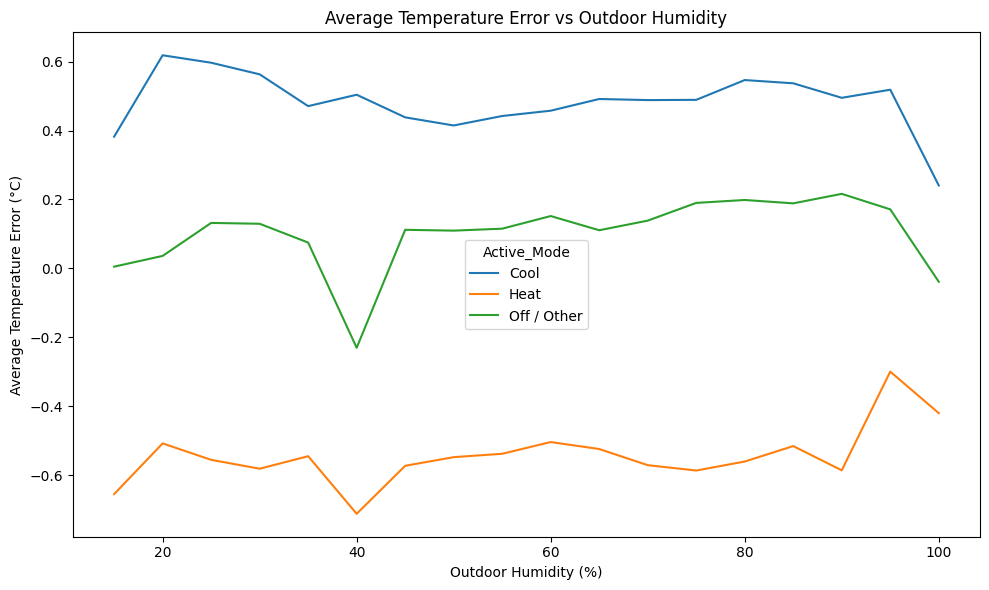

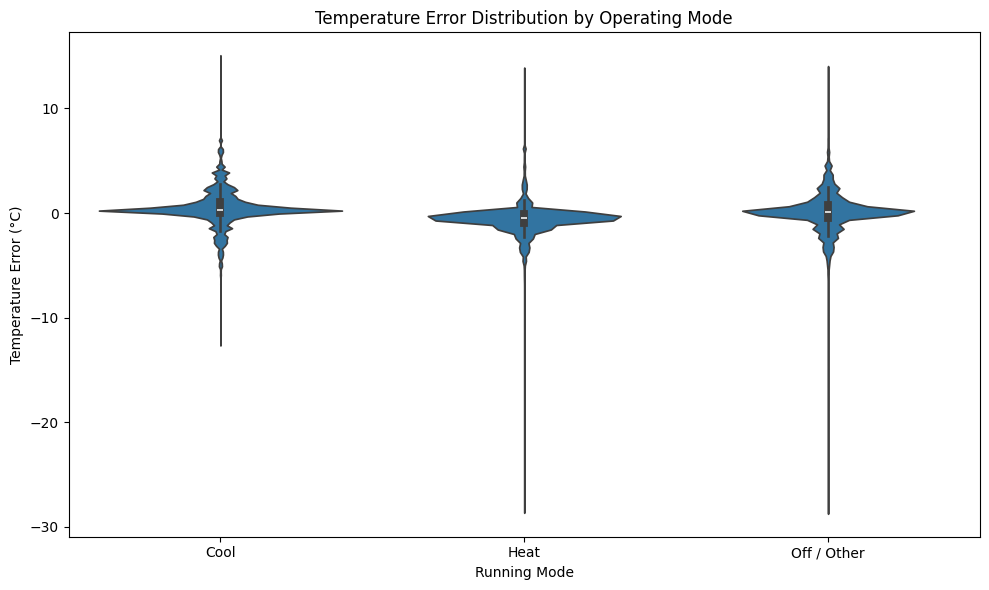

In [ ]:
#------------------------------------------------------------------------------
#
# block 12: environmental capabilities and mode errors
#
#------------------------------------------------------------------------------

# establish figure canvas for humidity capability
#
plt.figure(figsize=(10, 6))

# create a localized copy to prevent altering the master dataframe
#
hum_df = master_df.copy()

# round humidity to nearest 5% for binned trendline
#
hum_df['Humidity_Bin'] = (hum_df['outsideHumidity'] // 5) * 5
hum_bin_df = hum_df.groupby(['Humidity_Bin', 'Active_Mode'], observed=True)['Temperature_Error'].mean().reset_index()

# plot binned humidity vs average error
#
sns.lineplot(data=hum_bin_df, x='Humidity_Bin', y='Temperature_Error', hue='Active_Mode')

# configure labels
#
plt.title('Average Temperature Error vs Outdoor Humidity')
plt.xlabel('Outdoor Humidity (%)')
plt.ylabel('Average Temperature Error (°C)')
plt.tight_layout()
plt.show()

# establish figure canvas for error by mode
#
plt.figure(figsize=(10, 6))

# plot error distribution by operating mode across the full dataset
#
sns.violinplot(data=master_df, x='Active_Mode', y='Temperature_Error')

# configure labels
#
plt.title('Temperature Error Distribution by Operating Mode')
plt.xlabel('Running Mode')
plt.ylabel('Temperature Error (°C)')
plt.tight_layout()
plt.show()

#
# end of file

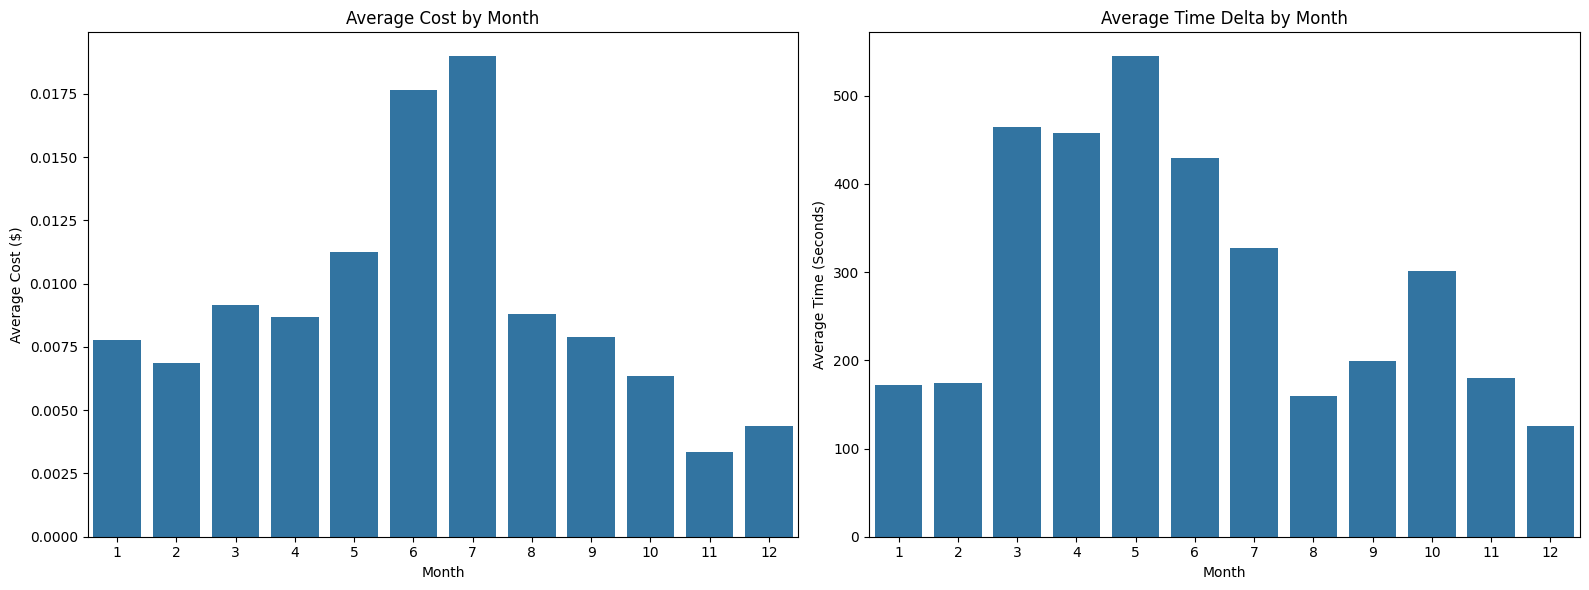

In [ ]:
#------------------------------------------------------------------------------
#
# block 13: seasonality analysis
#
#------------------------------------------------------------------------------

# calculate average metrics by month
#
monthly_metrics = master_df.groupby('Month')[['Cost_Diff', 'Time_Delta']].mean().reset_index()

# establish subplots canvas
#
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# plot average Cost_Diff by Month
#
sns.barplot(data=monthly_metrics, x='Month', y='Cost_Diff', ax=axes[0])
axes[0].set_title('Average Cost by Month')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Average Cost ($)')

# plot average Time_Delta by Month
#
sns.barplot(data=monthly_metrics, x='Month', y='Time_Delta', ax=axes[1])
axes[1].set_title('Average Time Delta by Month')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Average Time (Seconds)')

# commit layout
#
plt.tight_layout()
plt.show()

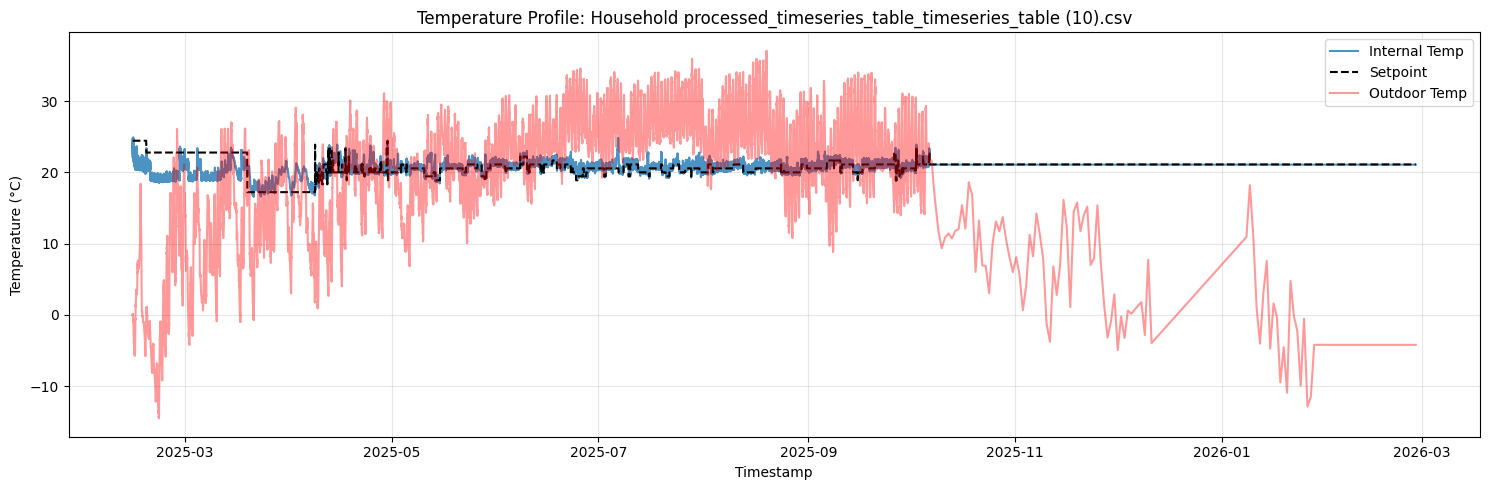

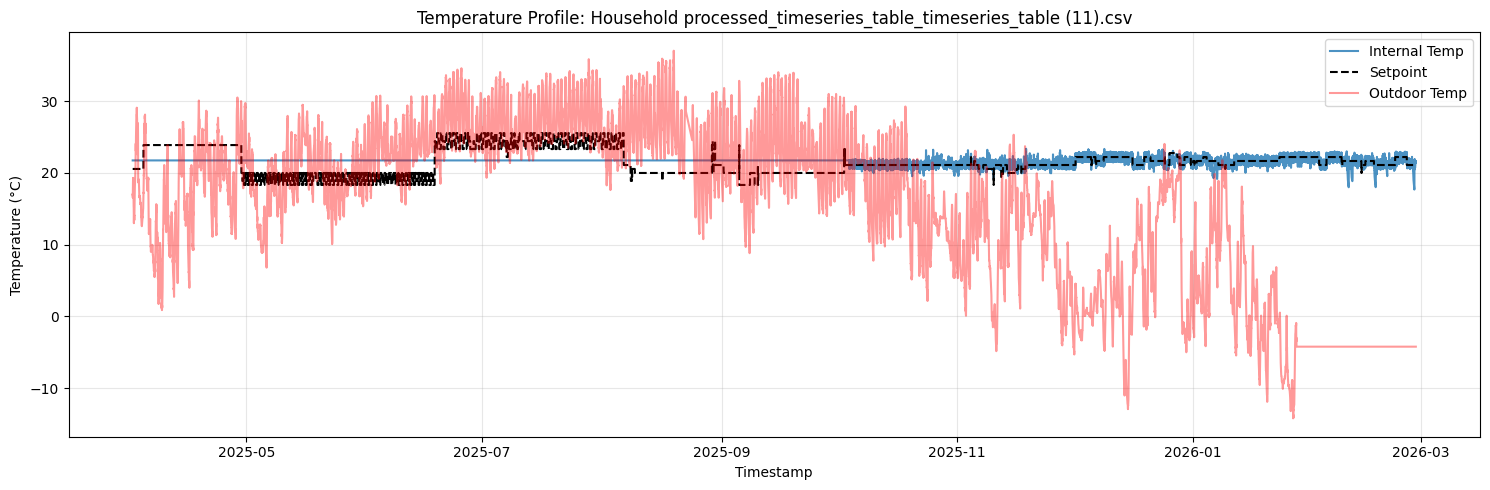

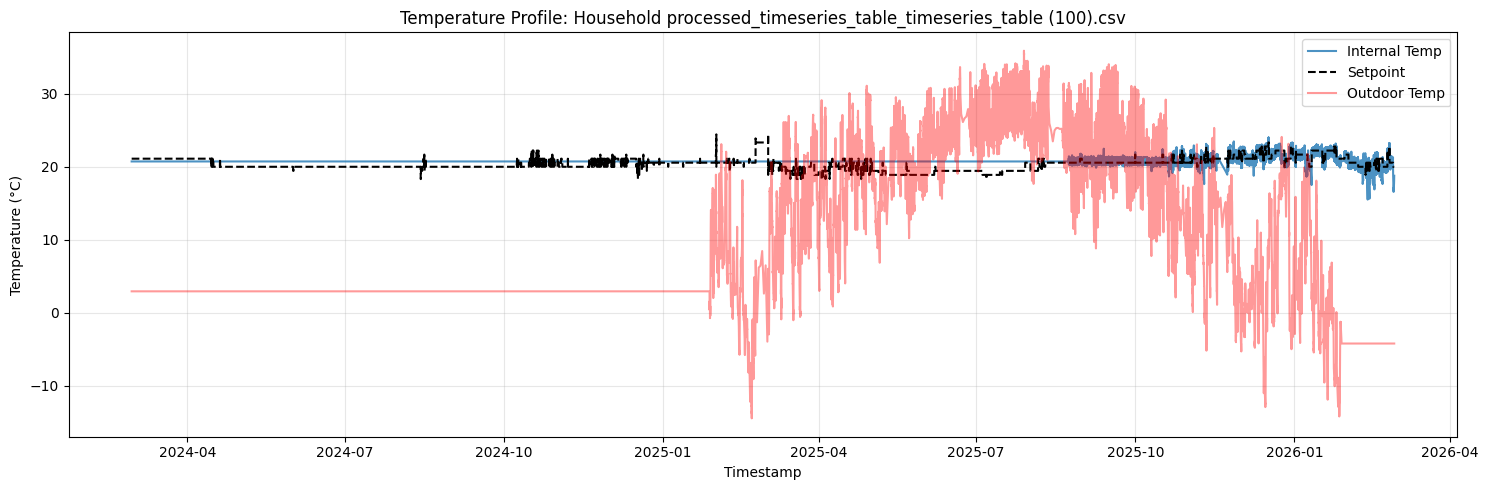

In [ ]:
#------------------------------------------------------------------------------
#
# block 16: individual household time-series visualization
#
#------------------------------------------------------------------------------

# identify a few unique households to visualize
#
sample_houses = master_df['House_ID'].unique()[:3]

for house in sample_houses:

    # filter data for the specific house and sort by time
    #
    house_data = master_df[master_df['House_ID'] == house].sort_values('Timestamp')

    # establish figure
    #
    plt.figure(figsize=(15, 5))

    # plot internal temp, setpoint, and outdoor temp
    #
    plt.plot(house_data['Timestamp'], house_data['Temperature'], label='Internal Temp', alpha=0.8)
    plt.plot(house_data['Timestamp'], house_data['Setpoint'], label='Setpoint', linestyle='--', color='black')
    plt.plot(house_data['Timestamp'], house_data['Outdoor_Temperature'], label='Outdoor Temp', alpha=0.4, color='red')

    # formatting
    #
    plt.title(f'Temperature Profile: Household {house}')
    plt.xlabel('Timestamp')
    plt.ylabel('Temperature (°C)')
    plt.legend(loc='upper right')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

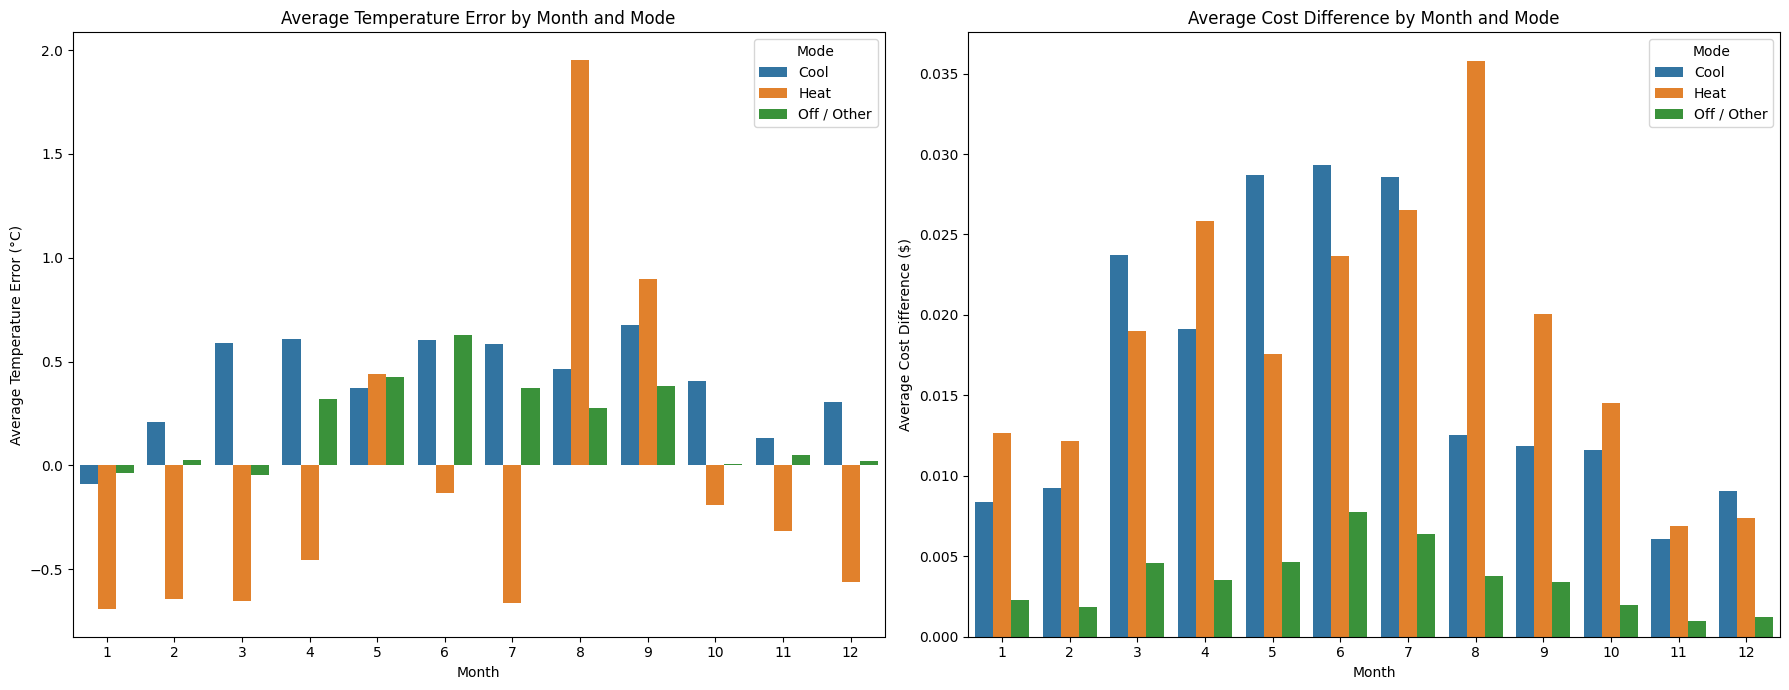

In [ ]:
#------------------------------------------------------------------------------
#
# block 17: seasonality clustered analysis
#
#------------------------------------------------------------------------------

# group master_df by month and active mode to find averages of key metrics
#
seasonal_clustered = master_df.groupby(['Month', 'Active_Mode'], observed=True)[['Temperature_Error', 'Cost_Diff']].mean().reset_index()

# initialize a matplotlib figure with two subplots
#
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# first subplot: average temperature error by month and mode
#
sns.barplot(data=seasonal_clustered, x='Month', y='Temperature_Error', hue='Active_Mode', ax=axes[0])
axes[0].set_title('Average Temperature Error by Month and Mode')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Average Temperature Error (°C)')
axes[0].legend(title='Mode', loc='upper right')

# second subplot: average cost difference by month and mode
#
sns.barplot(data=seasonal_clustered, x='Month', y='Cost_Diff', hue='Active_Mode', ax=axes[1])
axes[1].set_title('Average Cost Difference by Month and Mode')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Average Cost Difference ($)')
axes[1].legend(title='Mode', loc='upper right')

# apply tight layout and display plots
#
plt.tight_layout()
plt.show()

In [ ]:
#------------------------------------------------------------------------------
#
# block 19: formal statistical testing (cda)
#
#------------------------------------------------------------------------------

# import necessary stats module from scipy
#
import scipy.stats as stats

# isolate valid temperature errors and active modes, dropping nans
#
valid_df = master_df[['Active_Mode', 'Temperature_Error']].dropna()

# create a list of temperature error arrays grouped by active mode
#
groups = [group['Temperature_Error'].values for name, group in valid_df.groupby('Active_Mode', observed=True)]

# perform one-way anova test
#
f_stat, p_value = stats.f_oneway(*groups)

# print the results of the test
#
print(f"one-way anova results for temperature error across active modes:")
print(f"f-statistic: {f_stat:.4f}")
print(f"p-value: {p_value:.4e}")

one-way anova results for temperature error across active modes:
f-statistic: 468012.0312
p-value: 0.0000e+00
conclusion: there is a statistically significant difference in temperature error across different operating modes.


Average Seasonal Active Rates:
Winter: 51.64%
Spring: 29.09%
Summer: 54.67%
Fall: 45.22%

One-Way ANOVA results across seasons:
F-statistic: 100700.8704
p-value: 0.0000e+00
Conclusion: Supported. Workloads vary significantly by season.


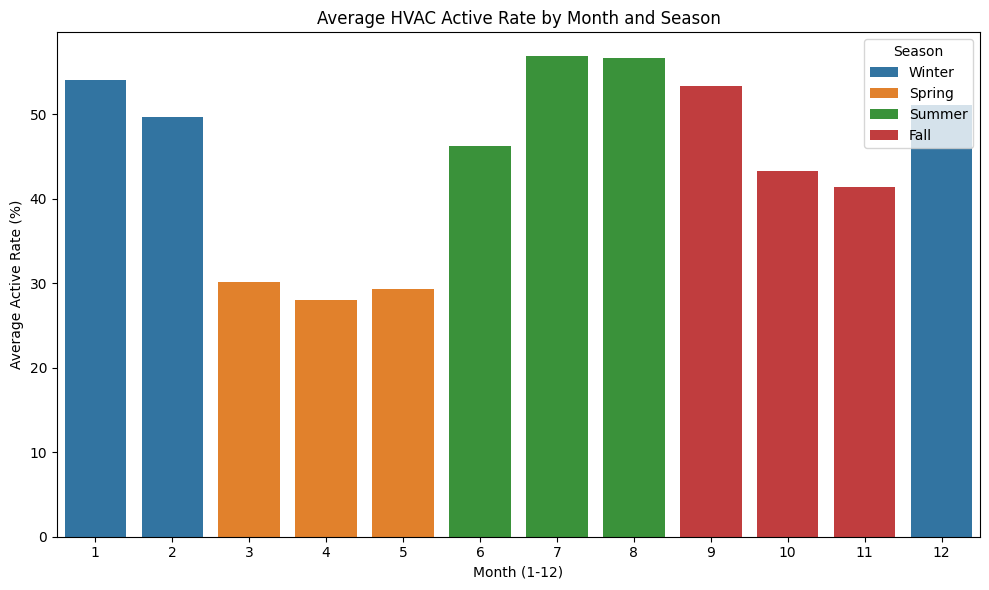

In [ ]:

if 'Month' not in master_df.columns:
    master_df['Month'] = master_df['Timestamp'].dt.month

def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Fall'

master_df['Season'] = master_df['Month'].apply(get_season)
master_df['Season'] = pd.Categorical(master_df['Season'], categories=['Winter', 'Spring', 'Summer', 'Fall'], ordered=True)

master_df['HVAC_Active'] = (master_df['Active_Mode'] != 'Off / Other').astype(int)

winter_active = master_df[master_df['Season'] == 'Winter']['HVAC_Active'].dropna().values
spring_active = master_df[master_df['Season'] == 'Spring']['HVAC_Active'].dropna().values
summer_active = master_df[master_df['Season'] == 'Summer']['HVAC_Active'].dropna().values
fall_active = master_df[master_df['Season'] == 'Fall']['HVAC_Active'].dropna().values

f_stat, p_value = stats.f_oneway(winter_active, spring_active, summer_active, fall_active)

season_avg = master_df.groupby('Season', observed=True)['HVAC_Active'].mean() * 100
print("Average Seasonal Active Rates:")
for season, avg in season_avg.items():
    print(f"{season}: {avg:.2f}%")

print(f"\nOne-Way ANOVA results across seasons:")
print(f"F-statistic: {f_stat:.4f}")
print(f"p-value: {p_value:.4e}")

if p_value < 0.05:
    print("Conclusion: Supported. Workloads vary significantly by season.")
else:
    print("Conclusion: Disproven. Workloads do not vary significantly by season.")

seasonal_activity = master_df.groupby(['Season', 'Month'], observed=True)['HVAC_Active'].mean().reset_index()
seasonal_activity = seasonal_activity.dropna()
seasonal_activity['HVAC_Active_Pct'] = seasonal_activity['HVAC_Active'] * 100

plt.figure(figsize=(10, 6))
sns.barplot(data=seasonal_activity, x='Month', y='HVAC_Active_Pct', hue='Season', dodge=False)
plt.title('Average HVAC Active Rate by Month and Season')
plt.xlabel('Month (1-12)')
plt.ylabel('Average Active Rate (%)')
plt.legend(title='Season', loc='upper right')
plt.tight_layout()
plt.show()

Peak Heating Hour: 7:00
Peak Cooling Hour: 18:00
Conclusion: Supported. Heating peaks in the early morning, and cooling peaks in the late afternoon.


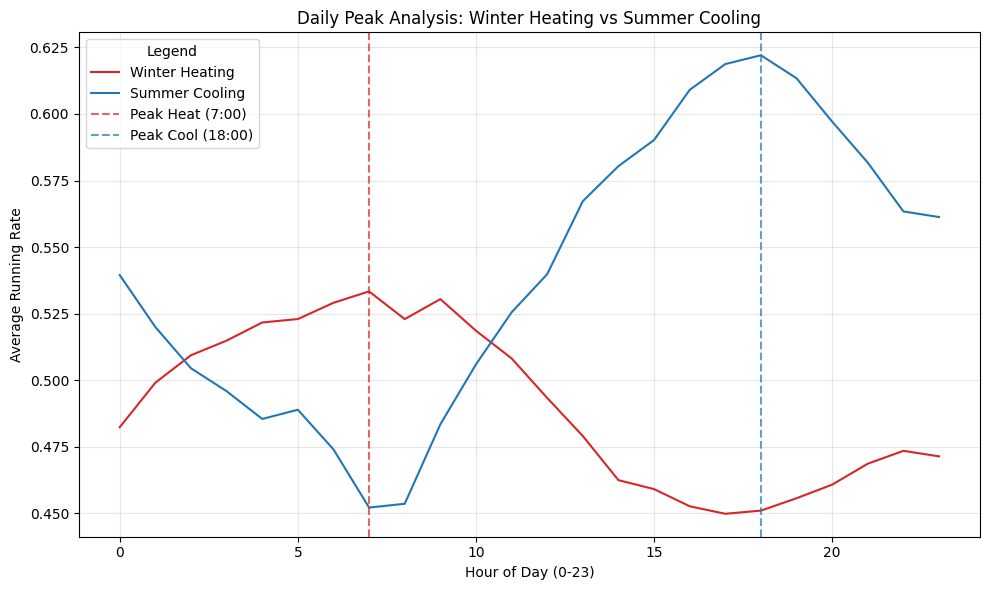

In [ ]:
# Data Report Quote: 'Heating peaks in the early morning, while cooling peaks in the late afternoon.'
#------------------------------------------------------------------------------
#
# block 23: daily peak analysis
#
#------------------------------------------------------------------------------

import matplotlib.pyplot as plt
import seaborn as sns

# ensure Season column exists just in case previous cells were skipped
if 'Season' not in master_df.columns:
    if 'Month' not in master_df.columns:
        master_df['Month'] = master_df['Timestamp'].dt.month
    def get_season(month):
        if month in [12, 1, 2]: return 'Winter'
        elif month in [3, 4, 5]: return 'Spring'
        elif month in [6, 7, 8]: return 'Summer'
        else: return 'Fall'
    master_df['Season'] = master_df['Month'].apply(get_season)

# create separate dataframes for winter and summer
#
winter_df = master_df[master_df['Season'] == 'Winter'].copy()
summer_df = master_df[master_df['Season'] == 'Summer'].copy()

# calculate boolean active states and convert to int for mean calculation
#
winter_df['Heat_Active'] = (winter_df['Active_Mode'] == 'Heat').astype(int)
summer_df['Cool_Active'] = (summer_df['Active_Mode'] == 'Cool').astype(int)

# group by hour and calculate the mean running rate
#
winter_hourly_heat = winter_df.groupby('Hour')['Heat_Active'].mean().reset_index()
summer_hourly_cool = summer_df.groupby('Hour')['Cool_Active'].mean().reset_index()

# identify exact peak hours
peak_heat_hour = winter_hourly_heat.loc[winter_hourly_heat['Heat_Active'].idxmax(), 'Hour']
peak_cool_hour = summer_hourly_cool.loc[summer_hourly_cool['Cool_Active'].idxmax(), 'Hour']

print(f"Peak Heating Hour: {int(peak_heat_hour)}:00")
print(f"Peak Cooling Hour: {int(peak_cool_hour)}:00")

# define time ranges for early morning and late afternoon
early_morning = range(4, 10) # 4 AM to 9 AM inclusive
late_afternoon = range(14, 20) # 2 PM to 7 PM inclusive

# check conditions
heat_in_morning = peak_heat_hour in early_morning
cool_in_afternoon = peak_cool_hour in late_afternoon

if heat_in_morning and cool_in_afternoon:
    print("Conclusion: Supported. Heating peaks in the early morning, and cooling peaks in the late afternoon.")
elif heat_in_morning:
    print("Conclusion: Partially supported. Heating peaks early morning, but cooling does not peak late afternoon.")
elif cool_in_afternoon:
    print("Conclusion: Partially supported. Cooling peaks late afternoon, but heating does not peak early morning.")
else:
    print("Conclusion: Disproven. Neither peak occurs during the hypothesized times.")

# establish figure canvas
#
plt.figure(figsize=(10, 6))

# plot winter heating and summer cooling
#
sns.lineplot(data=winter_hourly_heat, x='Hour', y='Heat_Active', label='Winter Heating', color='tab:red')
sns.lineplot(data=summer_hourly_cool, x='Hour', y='Cool_Active', label='Summer Cooling', color='tab:blue')

# annotate peaks with vertical lines
#
plt.axvline(x=peak_heat_hour, color='tab:red', linestyle='--', alpha=0.7, label=f'Peak Heat ({int(peak_heat_hour)}:00)')
plt.axvline(x=peak_cool_hour, color='tab:blue', linestyle='--', alpha=0.7, label=f'Peak Cool ({int(peak_cool_hour)}:00)')

# configure labels, title, and legend
#
plt.title('Daily Peak Analysis: Winter Heating vs Summer Cooling')
plt.xlabel('Hour of Day (0-23)')
plt.ylabel('Average Running Rate')
plt.legend(title='Legend', loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


Absolute Correlation with Daily Runtime (Seconds) across ALL features:
OutputState          0.884431
CumulativeCost       0.696275
CumulativeRuntime    0.696275
Time_Delta           0.663767
outsideHumidity      0.652728
RunningMode_off      0.590027
HVAC_Active          0.590027
FanState             0.510020
outsideMaxTemp       0.450357
Outdoor_Bin          0.431921
Name: Runtime_Diff, dtype: float64


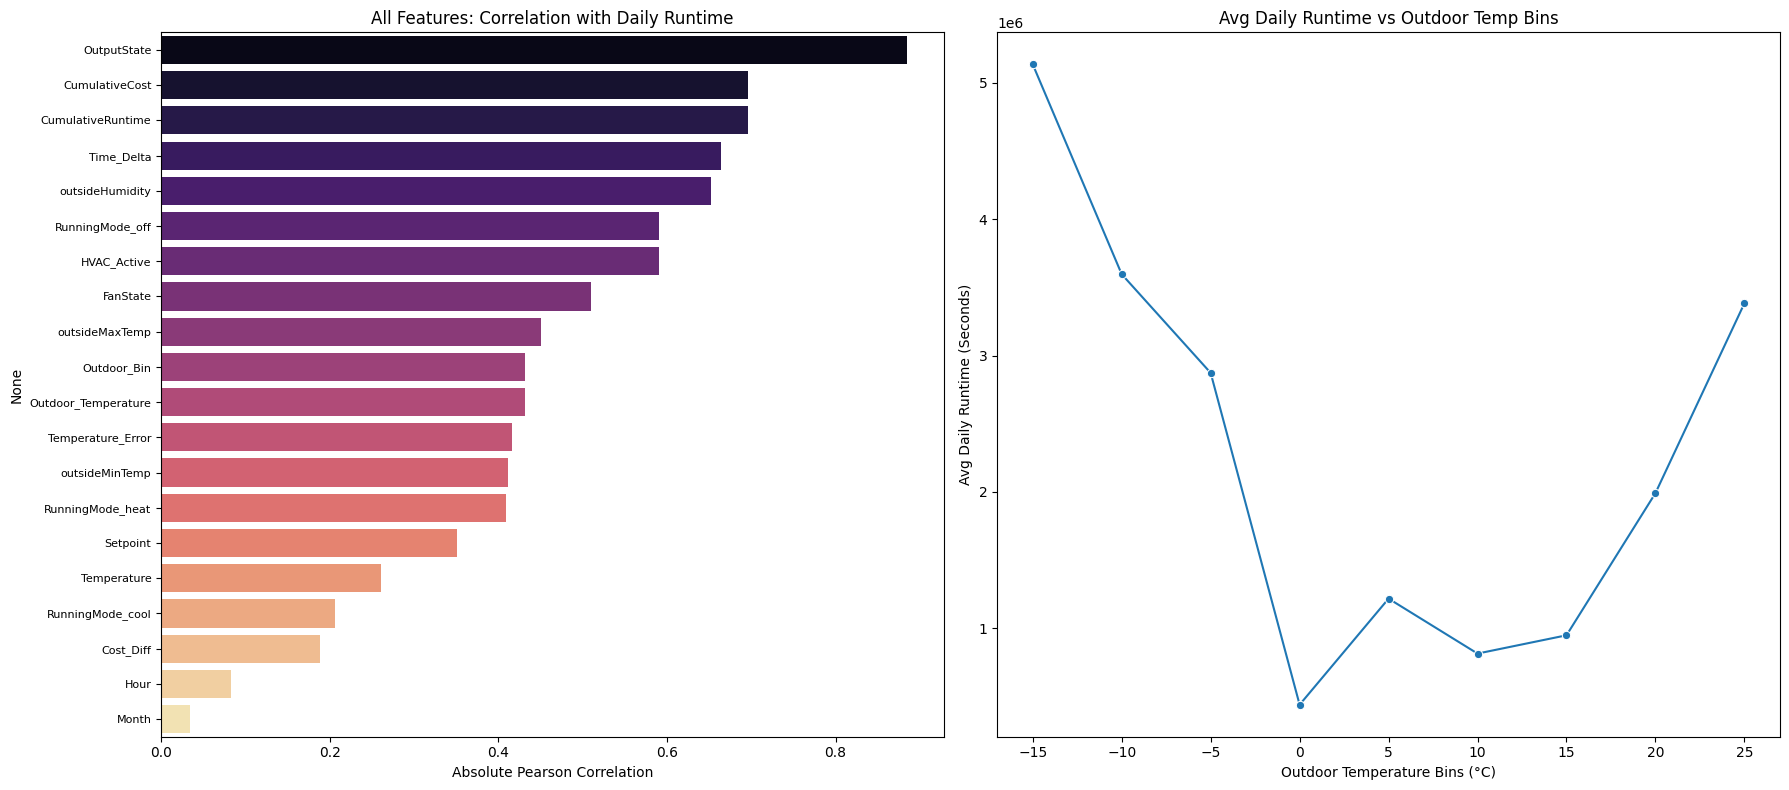

In [ ]:
# Data Report Quote: 'Outdoor temperature is the most important factor for predicting daily runtime.'
#------------------------------------------------------------------------------
# block 24: workload vs outdoor temperature bins & full feature correlation
#------------------------------------------------------------------------------



master_df['Runtime_Diff'] = master_df['CumulativeRuntime'].diff().fillna(0).clip(lower=0)

# Select all numeric columns to dynamically include all features
numeric_cols = master_df.select_dtypes(include=['number']).columns.tolist()
numeric_cols.append('Runtime_Diff')

# Aggregate ALL numeric features to a daily level (using mean for most as a baseline)
daily_features = master_df.groupby('Date', observed=True)[numeric_cols].mean().reset_index()

# Overwrite the daily runtime with the sum (since it's a cumulative duration, sum makes more sense than mean)
daily_features['Runtime_Diff'] = master_df.groupby('Date', observed=True)['Runtime_Diff'].sum().values

# Calculate correlations with total Daily Runtime across ALL features
runtime_corrs = daily_features.corr(numeric_only=True)['Runtime_Diff'].abs().drop(['Runtime_Diff']).sort_values(ascending=False)

print("Absolute Correlation with Daily Runtime (Seconds) across ALL features:")
print(runtime_corrs.head(10)) # printing top 10 to keep logs clean

# Plotting
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Bar chart for all feature correlations
sns.barplot(x=runtime_corrs.values, y=runtime_corrs.index, ax=axes[0], palette='magma')
axes[0].set_title('All Features: Correlation with Daily Runtime')
axes[0].set_xlabel('Absolute Pearson Correlation')
axes[0].tick_params(axis='y', labelsize=8)

# U-Curve: Daily Runtime vs Outdoor Temp
# Bin the average daily outdoor temperature
daily_features['Temp_Bin'] = (daily_features['Outdoor_Temperature'] // 5) * 5
bin_runtime = daily_features.groupby('Temp_Bin')['Runtime_Diff'].mean().reset_index()

sns.lineplot(data=bin_runtime, x='Temp_Bin', y='Runtime_Diff', marker='o', ax=axes[1])
axes[1].set_title('Avg Daily Runtime vs Outdoor Temp Bins')
axes[1].set_ylabel('Avg Daily Runtime (Seconds)')
axes[1].set_xlabel('Outdoor Temperature Bins (°C)')

plt.tight_layout()
plt.show()


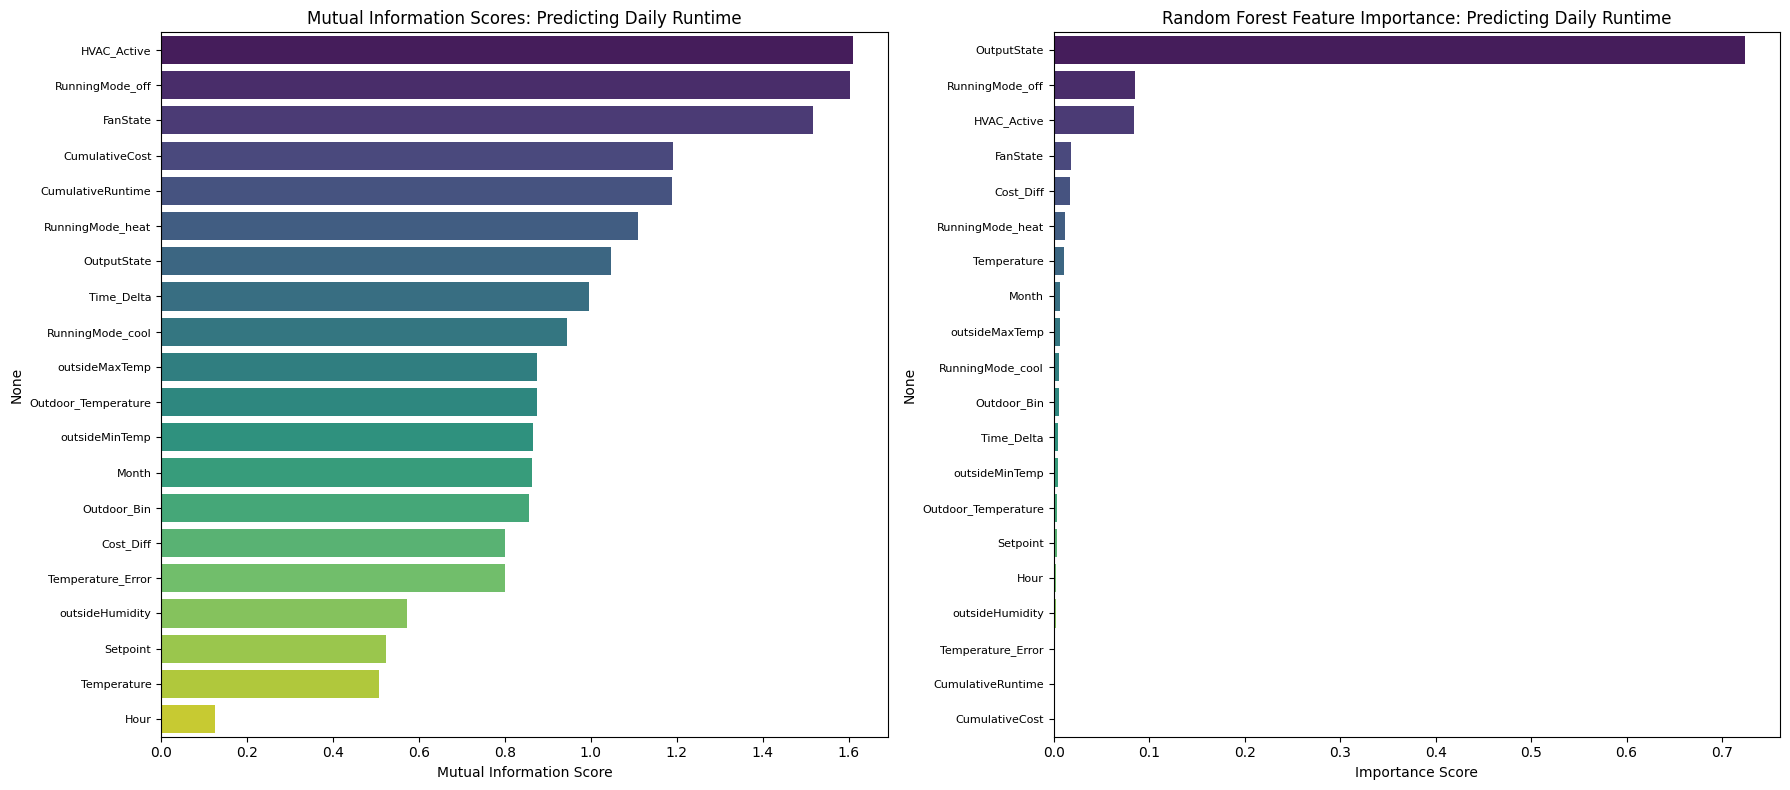

In [ ]:
#------------------------------------------------------------------------------
# block 25: Mutual Information & Feature Importance for Daily Runtime
#------------------------------------------------------------------------------

from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import mutual_info_regression

# Prepare dataset for daily runtime prediction dropping NaNs
model_data = daily_features.dropna()

# Target
y = model_data['Runtime_Diff']

# Predictors: Use ALL numeric columns except the target, dates, or synthetic bins
ignore_cols = ['Runtime_Diff', 'Date', 'Temp_Bin']
X = model_data.drop(columns=[col for col in ignore_cols if col in model_data.columns])
X = X.select_dtypes(include=['number'])

# 1. Calculate Mutual Information Scores
mi_scores = mutual_info_regression(X, y, random_state=42)
mi_series = pd.Series(mi_scores, index=X.columns).sort_values(ascending=False)

# 2. Use a Random Forest to get feature importances
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X, y)
rf_importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)

# Plotting Both Metrics Side-by-Side
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Mutual Information Plot
sns.barplot(x=mi_series.values, y=mi_series.index, palette='viridis', ax=axes[0])
axes[0].set_title('Mutual Information Scores: Predicting Daily Runtime')
axes[0].set_xlabel('Mutual Information Score')
axes[0].tick_params(axis='y', labelsize=8)

# Random Forest Importances Plot
sns.barplot(x=rf_importances.values, y=rf_importances.index, palette='viridis', ax=axes[1])
axes[1].set_title('Random Forest Feature Importance: Predicting Daily Runtime')
axes[1].set_xlabel('Importance Score')
axes[1].tick_params(axis='y', labelsize=8)

plt.tight_layout()
plt.show()
